In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully")

All libraries imported successfully


In [12]:
df = pd.read_csv("../datasets/European_Bank.csv")

In [13]:
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [15]:
df.shape

(10000, 14)

In [16]:
df.columns

Index(['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [18]:
df.isnull().sum()

Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [21]:
df['Exited'].value_counts(normalize=True)*100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

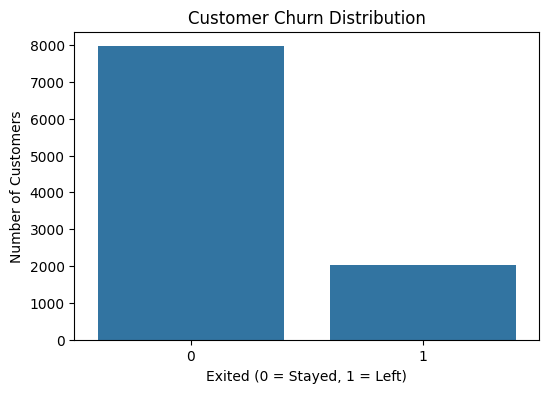

In [22]:
plt.figure(figsize=(6,4))

sns.countplot(x='Exited', data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Exited (0 = Stayed, 1 = Left)")
plt.ylabel("Number of Customers")

plt.show()

In [23]:
geo_churn = df.groupby('Geography')['Exited'].mean()*100

geo_churn

Geography
France     16.154767
Germany    32.443204
Spain      16.673395
Name: Exited, dtype: float64

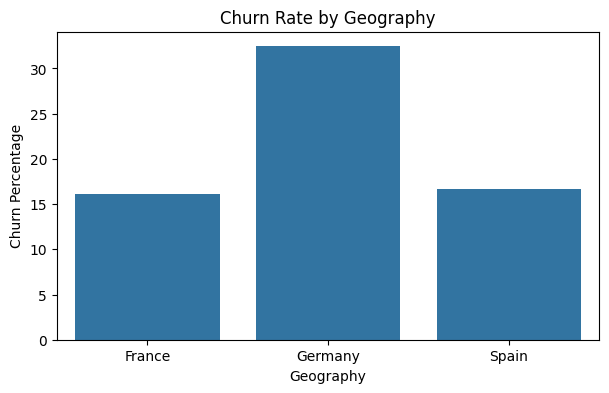

In [24]:
plt.figure(figsize=(7,4))

sns.barplot(
    x=geo_churn.index,
    y=geo_churn.values
)

plt.title("Churn Rate by Geography")
plt.ylabel("Churn Percentage")

plt.show()

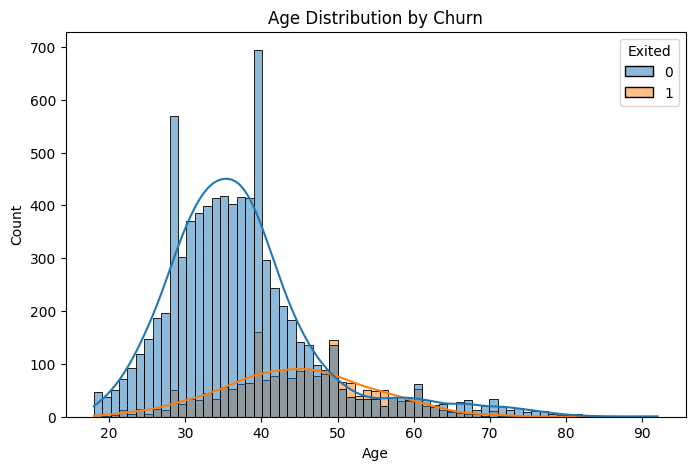

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='Age',
    hue='Exited',
    kde=True
)

plt.title("Age Distribution by Churn")

plt.show()

In [26]:
active_churn = df.groupby('IsActiveMember')['Exited'].mean()*100

active_churn

IsActiveMember
0    26.850897
1    14.269074
Name: Exited, dtype: float64

In [27]:
product_churn = df.groupby('NumOfProducts')['Exited'].mean()*100

product_churn

NumOfProducts
1     27.714398
2      7.581699
3     82.706767
4    100.000000
Name: Exited, dtype: float64

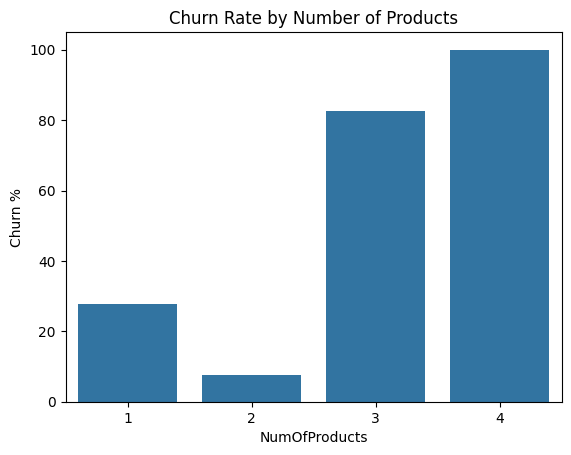

In [28]:
sns.barplot(
    x=product_churn.index,
    y=product_churn.values
)

plt.title("Churn Rate by Number of Products")

plt.ylabel("Churn %")

plt.show()

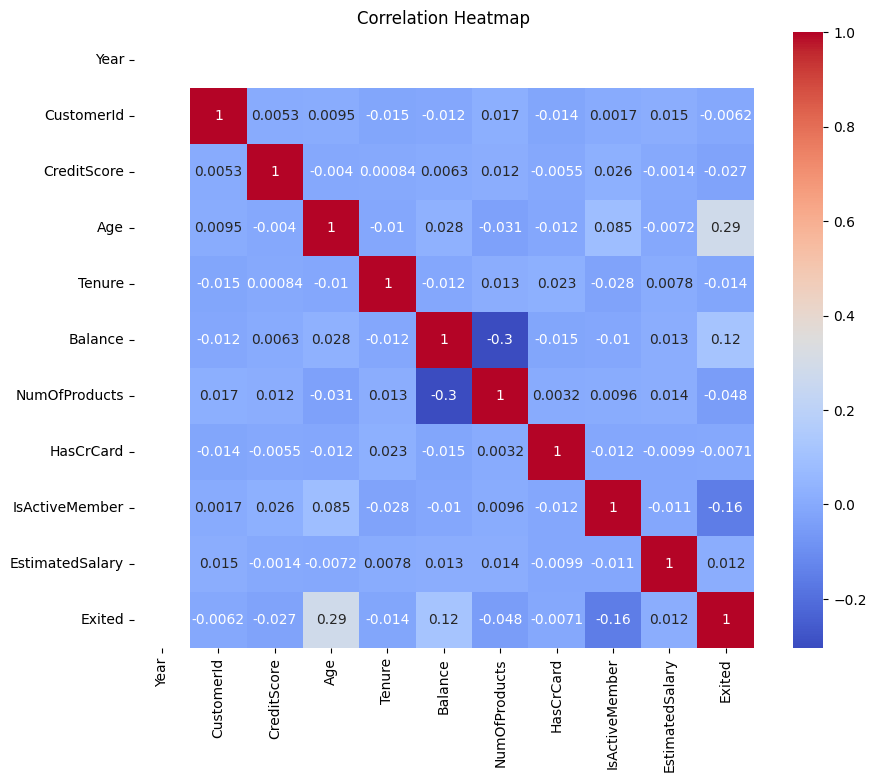

In [29]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [30]:
gender_churn = df.groupby('Gender')['Exited'].mean()*100

gender_churn

Gender
Female    25.071539
Male      16.455928
Name: Exited, dtype: float64

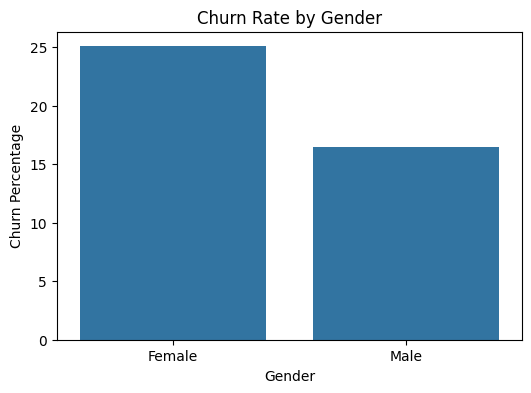

In [31]:
plt.figure(figsize=(6,4))

sns.barplot(
    x=gender_churn.index,
    y=gender_churn.values
)

plt.title("Churn Rate by Gender")
plt.ylabel("Churn Percentage")
plt.xlabel("Gender")

plt.show()

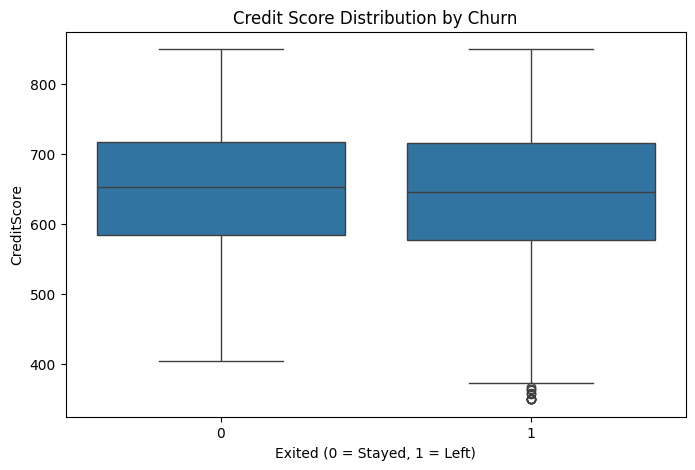

In [32]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Exited',
    y='CreditScore',
    data=df
)

plt.title("Credit Score Distribution by Churn")
plt.xlabel("Exited (0 = Stayed, 1 = Left)")

plt.show()

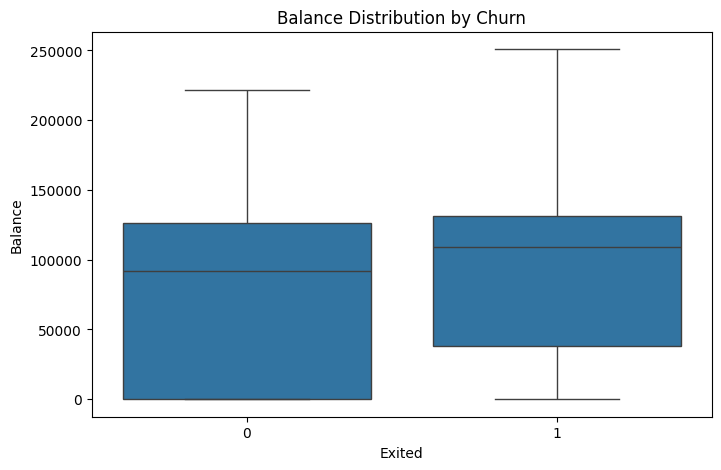

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Exited',
    y='Balance',
    data=df
)

plt.title("Balance Distribution by Churn")

plt.show()

In [34]:
tenure_churn = df.groupby('Tenure')['Exited'].mean()*100

tenure_churn

Tenure
0     23.002421
1     22.415459
2     19.179389
3     21.110010
4     20.525784
5     20.652174
6     20.268873
7     17.217899
8     19.219512
9     21.646341
10    20.612245
Name: Exited, dtype: float64

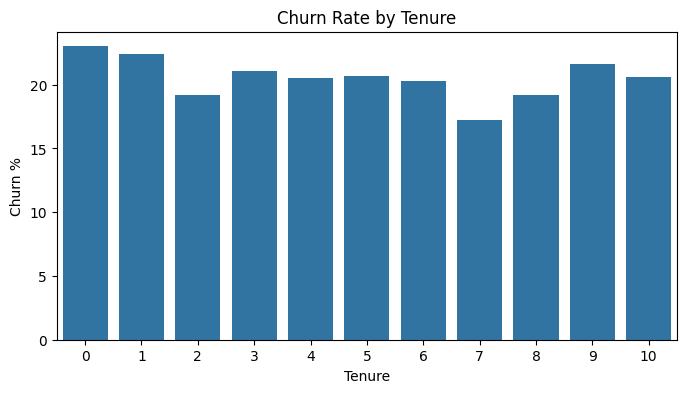

In [35]:
plt.figure(figsize=(8,4))

sns.barplot(
    x=tenure_churn.index,
    y=tenure_churn.values
)

plt.title("Churn Rate by Tenure")

plt.ylabel("Churn %")

plt.show()

In [36]:
card_churn = df.groupby('HasCrCard')['Exited'].mean()*100

card_churn

HasCrCard
0    20.814941
1    20.184266
Name: Exited, dtype: float64

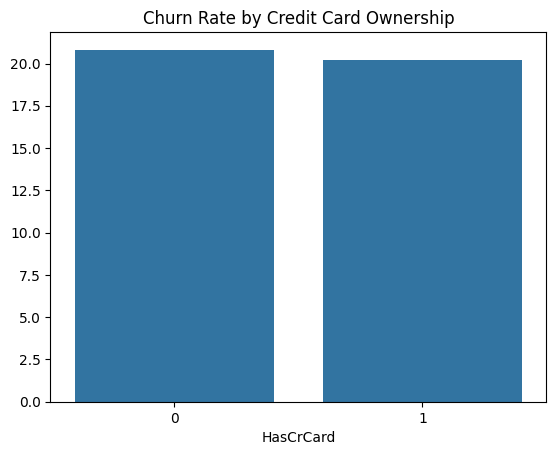

In [37]:
sns.barplot(
    x=card_churn.index,
    y=card_churn.values
)

plt.title("Churn Rate by Credit Card Ownership")

plt.show()

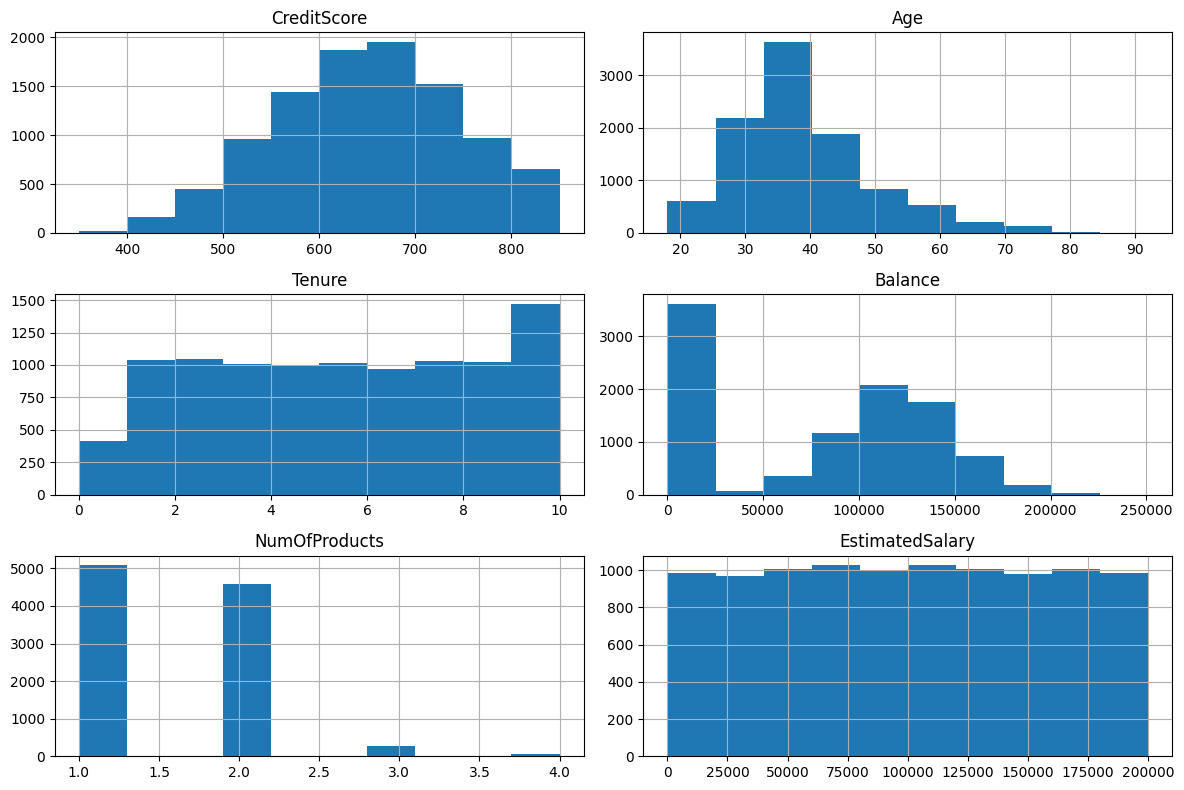

In [38]:
numeric_features = [
    'CreditScore',
    'Age',
    'Tenure',
    'Balance',
    'NumOfProducts',
    'EstimatedSalary'
]


df[numeric_features].hist(
    figsize=(12,8)
)

plt.tight_layout()

plt.show()

In [42]:
df.dtypes

Year                 int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [46]:
df = df.drop(['CustomerId','Surname','Year'])

KeyError: "['CustomerId', 'Surname', 'Year'] not found in axis"

In [47]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [48]:
df['BalanceSalaryRatio'] = df['Balance'] / df['EstimatedSalary']

In [49]:
df[['Balance','EstimatedSalary','BalanceSalaryRatio']].head()

,Balance,EstimatedSalary,BalanceSalaryRatio
0,0.00,101348.88,0.000000
1,83807.86,112542.58,0.744677
2,159660.80,113931.57,1.401375
3,0.00,93826.63,0.000000
4,125510.82,79084.10,1.587055


In [50]:
df['EngagementScore'] = (
    df['IsActiveMember'] +
    df['HasCrCard'] +
    df['NumOfProducts']
)

In [51]:
df[['IsActiveMember','HasCrCard','NumOfProducts','EngagementScore']].head()

,IsActiveMember,HasCrCard,NumOfProducts,EngagementScore
0,1,1,1,3
1,1,0,1,2
2,0,1,3,4
3,0,0,2,2
4,1,1,1,3


In [52]:
def age_group(age):
    if age < 30:
        return 'Young'
    elif age < 50:
        return 'Middle'
    else:
        return 'Senior'


df['AgeGroup'] = df['Age'].apply(age_group)

In [55]:
df[['Age','AgeGroup']].head()

,Age,AgeGroup
0,42,Middle
1,41,Middle
2,42,Middle
3,39,Middle
4,43,Middle


In [56]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,EngagementScore,AgeGroup
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.000000,3,Middle
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.744677,2,Middle
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1.401375,4,Middle
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.000000,2,Middle
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1.587055,3,Middle


In [57]:
df.dtypes

CreditScore             int64
Geography              object
Gender                 object
Age                     int64
Tenure                  int64
Balance               float64
NumOfProducts           int64
HasCrCard               int64
IsActiveMember          int64
EstimatedSalary       float64
Exited                  int64
BalanceSalaryRatio    float64
EngagementScore         int64
AgeGroup               object
dtype: object

In [58]:
  df.select_dtypes(include='object').columns

Index(['Geography', 'Gender', 'AgeGroup'], dtype='object')

In [59]:
df = pd.get_dummies(
    df,
    columns=['Geography','Gender','AgeGroup'],
    drop_first=True
)

In [61]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,EngagementScore,Geography_Germany,Geography_Spain,Gender_Male,AgeGroup_Senior,AgeGroup_Young
0,619,42,2,0.00,1,1,1,101348.88,1,0.000000,3,False,False,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,0.744677,2,False,True,False,False,False
2,502,42,8,159660.80,3,1,0,113931.57,1,1.401375,4,False,False,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,0.000000,2,False,False,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,1.587055,3,False,True,False,False,False


In [62]:
X = df.drop('Exited', axis=1)

In [63]:
y = df['Exited']

In [64]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [65]:
X_train.shape, X_test.shape

((8000, 15), (2000, 15))

In [66]:
from sklearn.preprocessing import StandardScaler

In [67]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [68]:
from sklearn.linear_model import LogisticRegression

In [69]:
log_model = LogisticRegression(
    random_state=42
)

In [70]:
log_model.fit(
    X_train_scaled,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [71]:
y_pred_log = log_model.predict(X_test_scaled)

In [72]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

In [73]:
print("Accuracy:",
      accuracy_score(y_test,y_pred_log))

print("Precision:",
      precision_score(y_test,y_pred_log))

print("Recall:",
      recall_score(y_test,y_pred_log))

print("F1 Score:",
      f1_score(y_test,y_pred_log))

Accuracy: 0.812
Precision: 0.6220472440944882
Recall: 0.1941031941031941
F1 Score: 0.2958801498127341


In [74]:
print(classification_report(y_test,y_pred_log))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.62      0.19      0.30       407

    accuracy                           0.81      2000
   macro avg       0.72      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



In [75]:
y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]

roc_auc_score(
    y_test,
    y_prob_log
)

0.7732647902139428

In [76]:
from sklearn.ensemble import RandomForestClassifier


rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)


rf_model.fit(
    X_train,
    y_train
)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [77]:
y_pred_rf = rf_model.predict(X_test)

In [78]:
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.78      0.42      0.55       407

    accuracy                           0.86      2000
   macro avg       0.82      0.70      0.73      2000
weighted avg       0.85      0.86      0.84      2000



In [79]:
from sklearn.ensemble import GradientBoostingClassifier


gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)


gb_model.fit(
    X_train,
    y_train
)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [80]:
y_pred_gb = gb_model.predict(X_test)

In [81]:
print(classification_report(y_test,y_pred_gb))

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.48      0.60       407

    accuracy                           0.87      2000
   macro avg       0.84      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



In [82]:
y_prob_gb = gb_model.predict_proba(X_test)[:,1]

roc_auc_score(
    y_test,
    y_prob_gb
)

0.869542886492039

In [83]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': gb_model.feature_importances_
})


feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)


feature_importance

,Feature,Importance
1,Age,0.383712
4,NumOfProducts,0.292268
6,IsActiveMember,0.098800
3,Balance,0.068626
10,Geography_Germany,0.051377
9,EngagementScore,0.030586
8,BalanceSalaryRatio,0.025750
0,CreditScore,0.018066
7,EstimatedSalary,0.013200
12,Gender_Male,0.013068


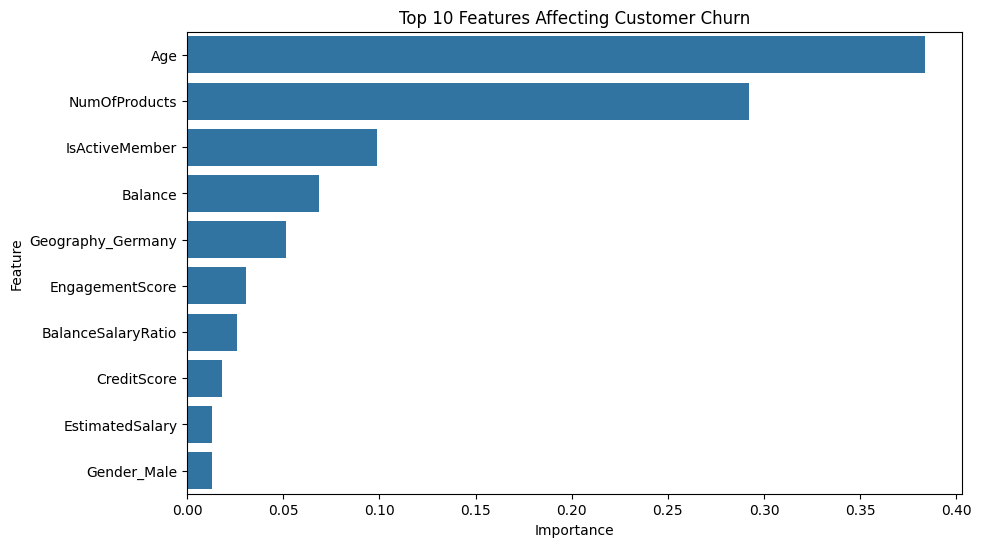

In [84]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Features Affecting Customer Churn")

plt.show()

In [85]:
risk_probability = gb_model.predict_proba(X_test)[:,1]

In [86]:
risk_probability[:10]

array([0.02248343, 0.08469454, 0.03741933, 0.06013342, 0.10193589,
       0.17897696, 0.05733023, 0.26095985, 0.51158064, 0.05765162])

In [87]:
def risk_category(probability):
    if probability < 0.4:
        return "Low Risk"
    elif probability < 0.7:
        return "Medium Risk"
    else:
        return "High Risk"


risk_category_list = [
    risk_category(prob)
    for prob in risk_probability
]

In [88]:
risk_df = X_test.copy()

risk_df['Churn Probability'] = risk_probability

risk_df['Risk Category'] = risk_category_list

risk_df['Actual Churn'] = y_test.values

In [91]:
risk_df.tail(20)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,BalanceSalaryRatio,EngagementScore,Geography_Germany,Geography_Spain,Gender_Male,AgeGroup_Senior,AgeGroup_Young,Churn Probability,Risk Category,Actual Churn
4883,614,43,8,140733.74,1,1,1,166588.76,0.844797,3,True,False,True,False,False,0.349442,Low Risk,0
152,716,42,8,0.00,2,1,0,180800.42,0.000000,3,False,True,True,False,False,0.034827,Low Risk,0
5264,547,44,5,0.00,3,0,0,5459.07,0.000000,3,False,True,False,False,False,0.831307,High Risk,1
1381,846,41,5,0.00,3,1,0,3440.47,0.000000,4,False,False,False,False,False,0.549038,Medium Risk,1
159,631,33,4,123246.70,1,0,0,112687.57,1.093703,1,True,False,False,False,False,0.256044,Low Risk,0
4920,515,33,2,0.00,2,1,1,136028.97,0.000000,4,False,False,True,False,False,0.015603,Low Risk,0
5886,607,40,5,90594.55,1,0,1,181598.25,0.498873,2,True,False,True,False,False,0.388606,Low Risk,0
3631,739,19,5,89750.21,1,1,0,193008.52,0.465006,2,False,True,True,False,True,0.138528,Low Risk,0
9164,680,36,7,0.00,2,1,0,20109.21,0.000000,3,False,True,True,False,False,0.023824,Low Risk,0
5750,747,37,9,135776.36,3,1,0,85470.45,1.588577,4,True,False,True,False,False,0.930580,High Risk,1


In [92]:
risk_df['Risk Category'].value_counts()

Risk Category
Low Risk       1679
Medium Risk     176
High Risk       145
Name: count, dtype: int64

In [93]:
risk_analysis = risk_df.groupby('Risk Category')['Actual Churn'].mean()*100

risk_analysis

Risk Category
High Risk      92.413793
Low Risk       11.018463
Medium Risk    50.000000
Name: Actual Churn, dtype: float64

In [94]:
import pickle

pickle.dump(
    gb_model,
    open("churn_model.pkl","wb")
)

In [95]:
pickle.dump(
    X_train.columns.tolist(),
    open("features.pkl","wb")
)

In [96]:
feature_importance.to_csv("feature_importance.csv", index=False)